# Fraud Detection
 Problem Statement:


 * Fraud detection in financial transactions is a critical challenge in the banking and fintech industries. This project aims to build a machine learning model to identify fraudulent transactions based on historical data. By analyzing key transaction features such as transaction amount, type, and accounts involved, we can uncover suspicious behaviors and improve fraud detection accuracy.

 Using feature engineering, data preprocessing, and model training, this project identifies high-risk transactions, helping financial institutions prevent fraud and enhance security.

# Importing Libraries & Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

* Loading the Dataset from the CSV file

In [3]:
df = pd.read_csv(r"C:\Users\dell\Downloads\Capstone Project\Fraud_Analysis_Dataset.csv")

In [6]:
df.head(15)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1
5,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.00,12145.85,1
6,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.00,9291619.62,1
7,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.00,0.00,1
8,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.00,2444985.19,1
9,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.00,0.00,1


In [8]:
df.tail(15)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
11127,7,CASH_OUT,210066.44,C1528391146,0.00,0.00,C295372946,499000.92,472083.92,0
11128,7,PAYMENT,2571.98,C2097824680,31115.00,28543.02,M1687989795,0.00,0.00,0
11129,7,PAYMENT,18046.61,C839913624,21146.00,3099.39,M573965573,0.00,0.00,0
11130,7,PAYMENT,8111.87,C219022824,16551.00,8439.13,M207769564,0.00,0.00,0
11131,7,TRANSFER,1298848.87,C1053035032,8439.13,0.00,C1787868648,1519512.39,15100000.00,0
11132,7,TRANSFER,731485.29,C751320808,0.00,0.00,C801142660,3504660.25,16400000.00,0
11133,7,TRANSFER,2943845.35,C1360289756,0.00,0.00,C1262822392,18000000.00,22600000.00,0
11134,7,TRANSFER,2861134.92,C1326904973,0.00,0.00,C991505714,5352935.74,14000000.00,0
11135,7,TRANSFER,80485.60,C1369223613,0.00,0.00,C465257140,1078685.56,1761413.49,0
11136,7,TRANSFER,19991.02,C1020193304,0.00,0.00,C1915624447,21586.00,17795.02,0


Data Description :
1. step - maps a unit of time in the real world. In this case 1 step is 1 hour of time.


2. type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

3. amount - amount of the transaction in local currency.

4. nameOrig - customer who started the transaction

5. oldbalanceOrg - initial balance before the transaction

6. newbalanceOrig - new balance after the transaction.

7. nameDest - customer who is the recipient of the transaction

8. oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers.

9. newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers.

10. isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to
profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

**Column Value Information**

* CASH-IN: Refers to depositing cash into an account, typically adding funds.

* CASH-OUT: Refers to withdrawing cash from an account, usually removing funds.

* DEBIT: This can have two meanings:

* It can refer to a decrease in the balance of a financial account due to a withdrawal or an expense.

* In accounting, it represents an entry that reduces assets or increases liabilities.

* PAYMENT: Refers to the transfer of money from one party (payer) to another (payee) in exchange for goods, services, or as settlement of a debt.

* TRANSFER: Refers to moving money from one account to another, often between accounts held by the same person or entity.

# EDA and Preprocessing

In [12]:
df.shape

(11142, 10)

* There are 11142 Rows and 10 Features

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


* There Majority of the features are Numeric
* And 3 Features are Categorical

In [17]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

* There are 9 Independent Features and 1 is a Dependent/Targeted Feature

In [64]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [65]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


* There is no missing/null value.
* Dataset seems to be cleaned.

In [66]:
df.duplicated().sum()

0

* There is no any duplicate value

In [67]:
df.nunique()

,0
step,95
type,5
amount,10565
nameOrig,11142
oldbalanceOrg,7806
newbalanceOrig,5914
nameDest,7508
oldbalanceDest,4531
newbalanceDest,2030
isFraud,2


* There 5 types of transactions method


In [20]:
df_cleaned = df.drop(['nameOrig', 'nameDest'], axis=1)

* Here we drop the Two features because the customers ID name doesn't make sense.
* Features Name :  'nameOrig' & 'nameDest' these features are unique identifiers

In [23]:
# Create new features
# Transaction differences and ratios
df_cleaned["balance_changeOrg"] = df_cleaned["newbalanceOrig"] - df_cleaned["oldbalanceOrg"]
df_cleaned["balance_changeDest"] = df_cleaned["newbalanceDest"] - df_cleaned["oldbalanceDest"]

In [25]:
df_cleaned.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_changeOrg,balance_changeDest
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,-181.0,0.0
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,-181.0,-21182.0
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,-2806.0,0.0
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,-2806.0,-26202.0
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,-20128.0,0.0


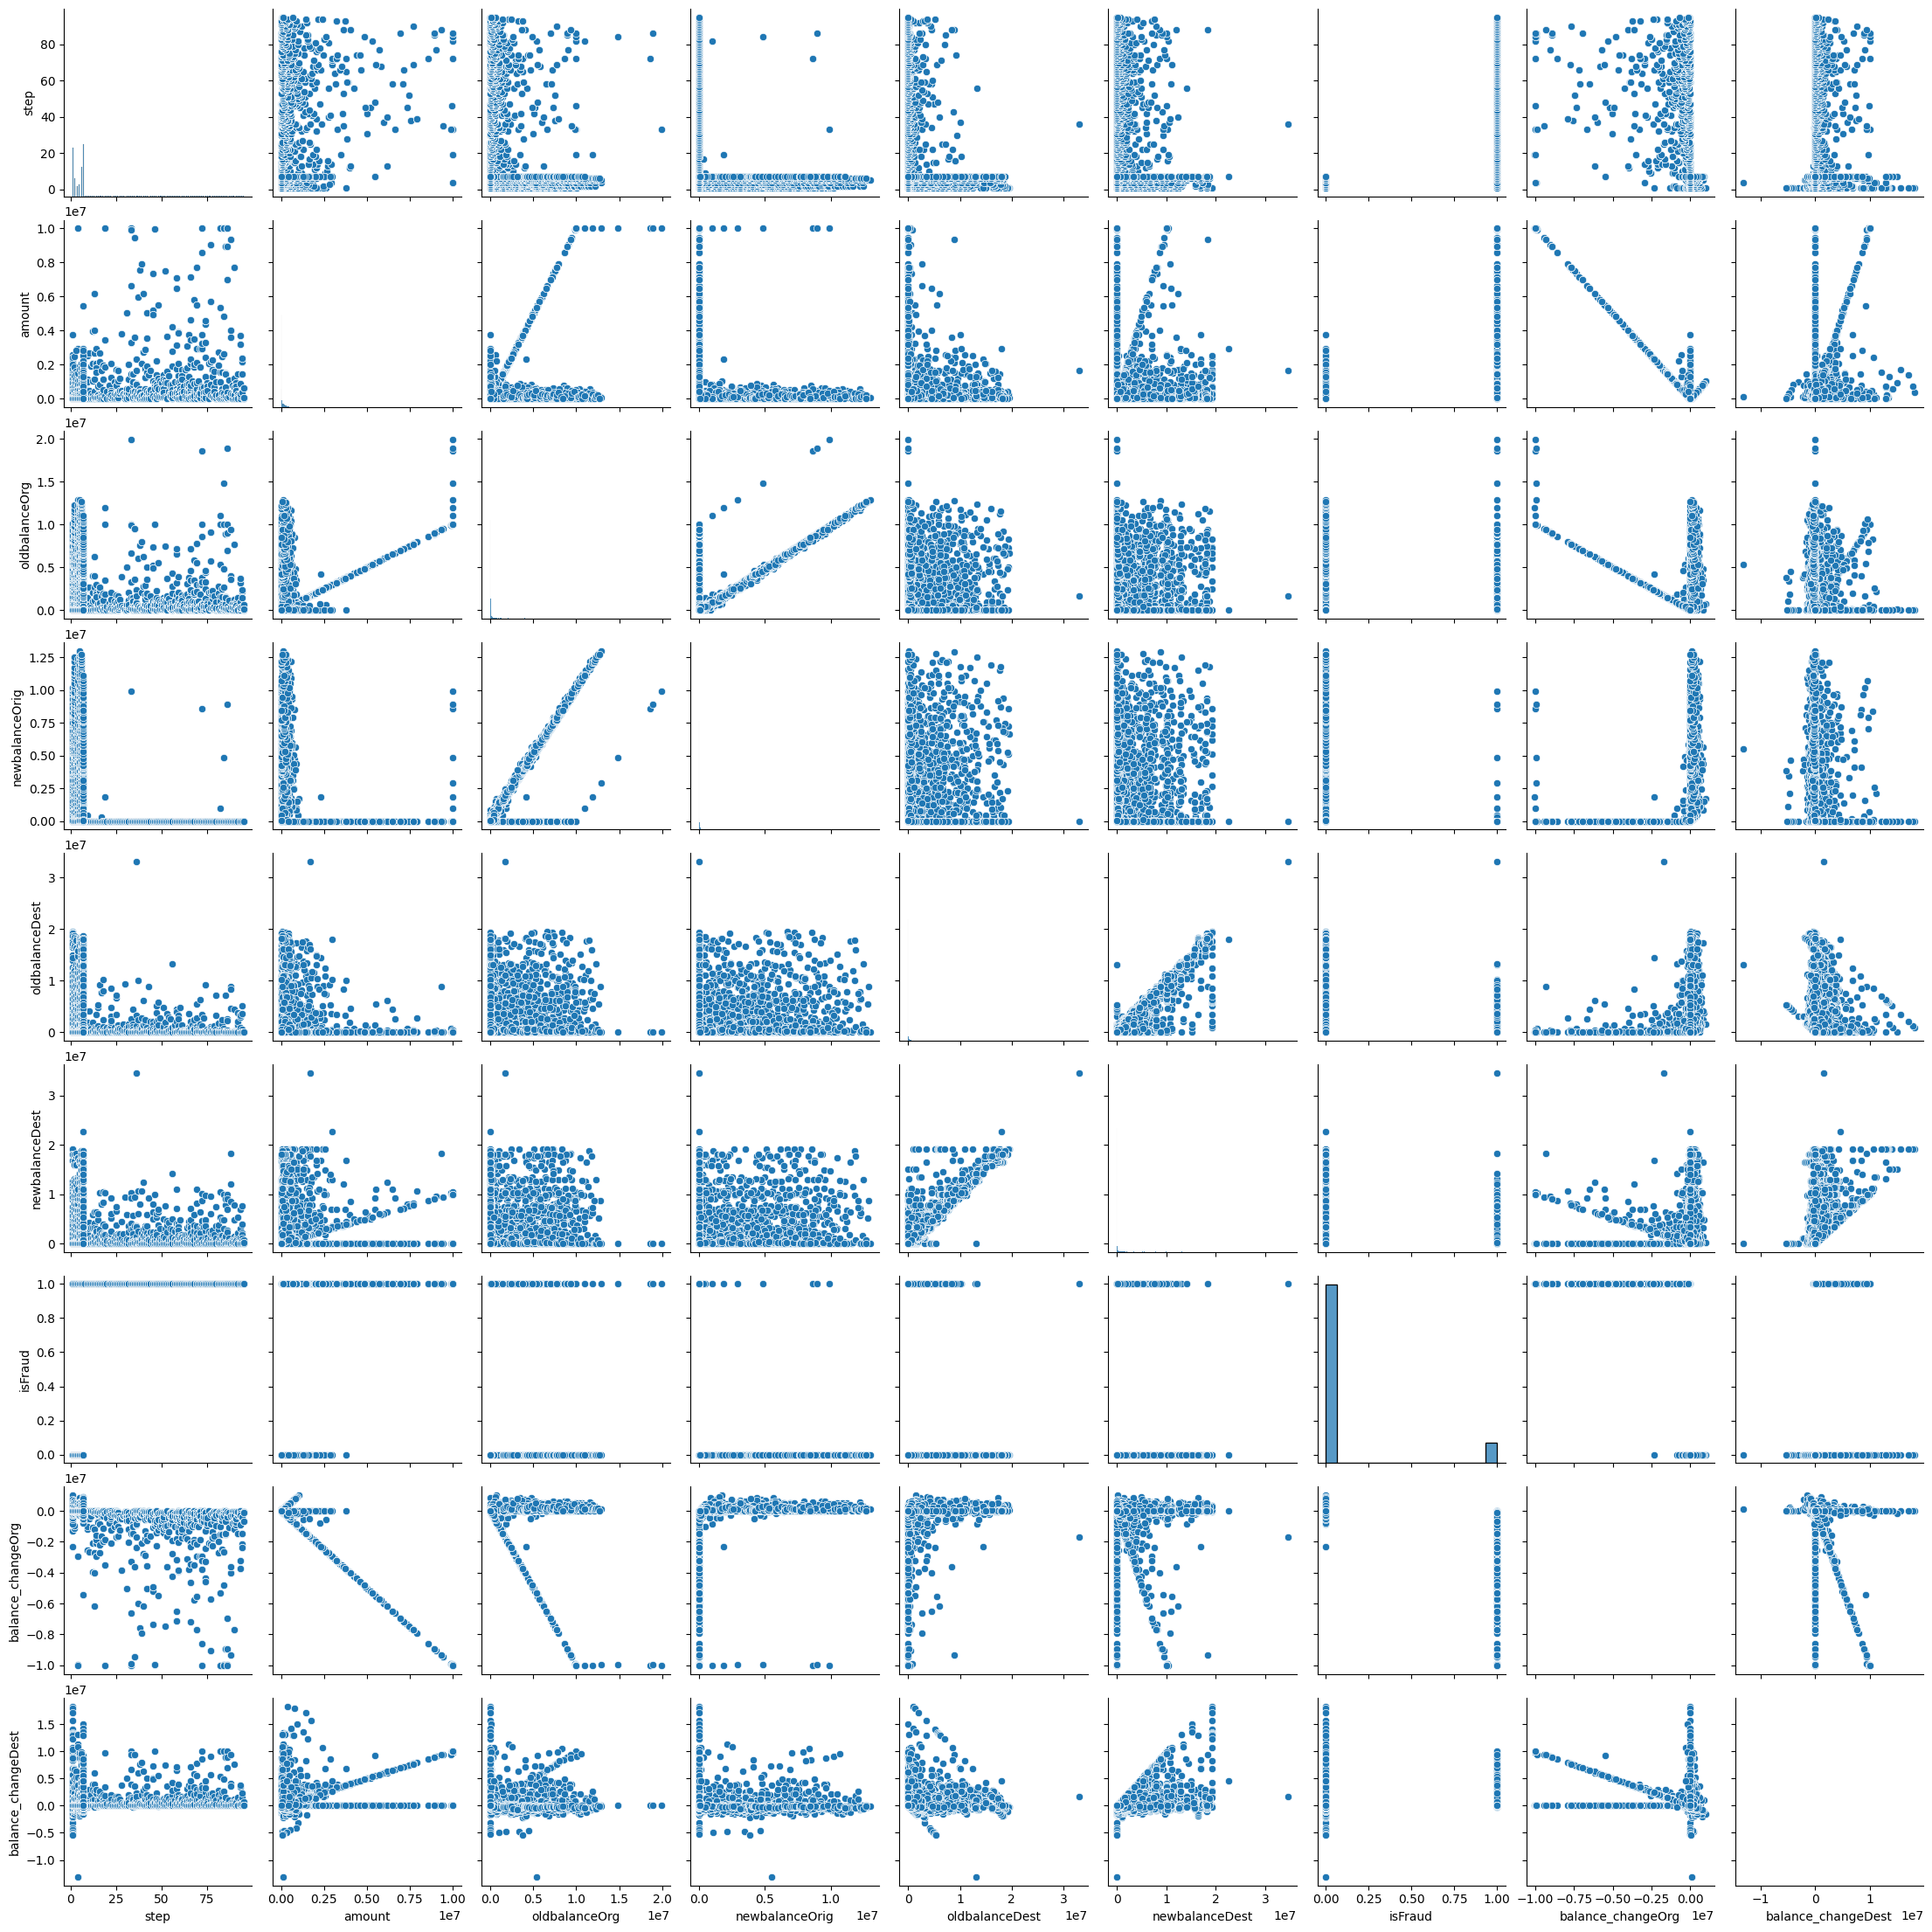

In [71]:
sns.pairplot(df_cleaned)

* Data seems to be Linear
* And There few features are highly positive correlation to each others.

## Multicolinearity

In [27]:
df_corr = df_cleaned.drop(['isFraud', 'type'], axis=1)

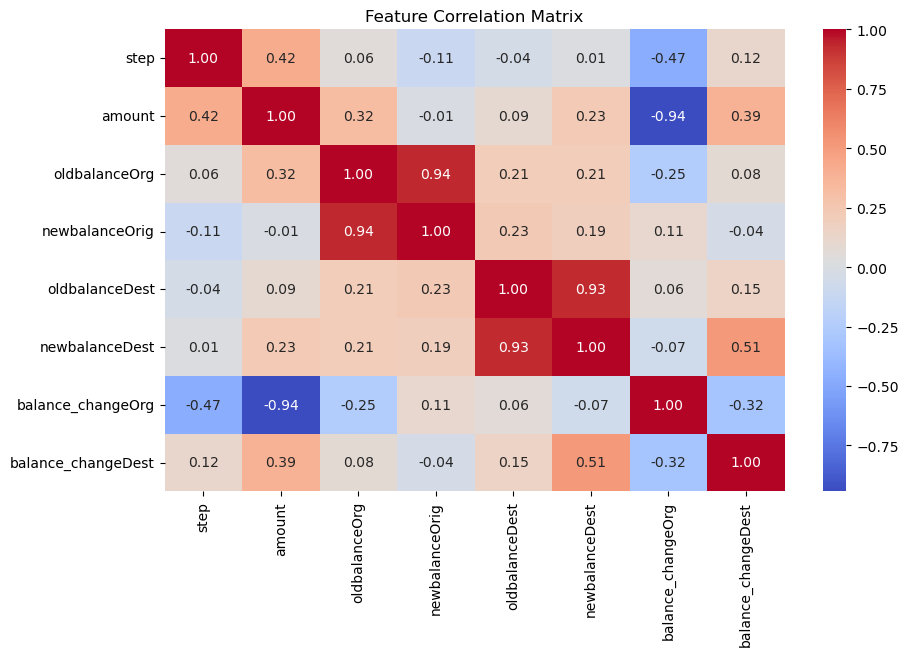

In [28]:
# Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

* There four features are highly correlated to each other
* But we'll go with these features we can't drop the features because there very less number of features

🔹 Balances before and after transactions are closely related (old balance and new balance are very similar).
🔹 If a transaction amount is high, the balance change at the origin is big (strong negative link).
🔹 Time (step) doesn’t affect balances much (weak connection).
🔹 Destination balances also behave the same way as origin balances (they are linked).

In [15]:
df_cleaned.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_changeOrg,balance_changeDest
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,-181.0,0.0
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,-181.0,-21182.0
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,-2806.0,0.0
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,-2806.0,-26202.0
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,-20128.0,0.0


Text(0.5, 1.0, 'Box Plot - Balance Change Destination')

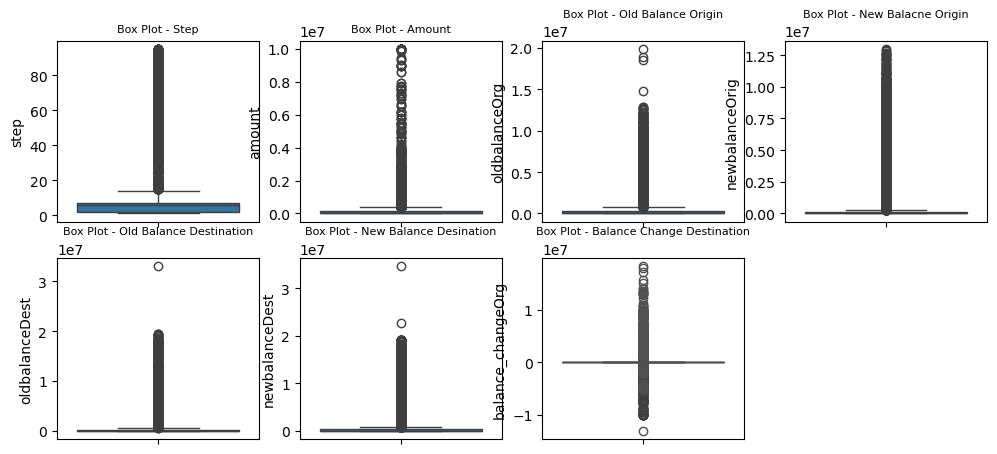

In [17]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 4, 1)
sns.boxplot(df_cleaned['step'])
plt.title('Box Plot - Step', fontsize=8)

plt.subplot(3, 4, 2)
sns.boxplot(df_cleaned['amount'])
plt.title('Box Plot - Amount', fontsize=8)

plt.subplot(3, 4, 3)
sns.boxplot(df_cleaned['oldbalanceOrg'])
plt.title('Box Plot - Old Balance Origin', fontsize=8)

plt.subplot(3, 4, 4)
sns.boxplot(df_cleaned['newbalanceOrig'])
plt.title('Box Plot - New Balacne Origin', fontsize=8)

plt.subplot(3, 4, 5)
sns.boxplot(df_cleaned['oldbalanceDest'])
plt.title('Box Plot - Old Balance Destination', fontsize=8)

plt.subplot(3, 4, 6)
sns.boxplot(df_cleaned['newbalanceDest'])
plt.title('Box Plot - New Balance Desination', fontsize=8)

plt.subplot(3, 4, 7)
sns.boxplot(df_cleaned['balance_changeOrg'])
plt.title('Box Plot - Balance Change Origin', fontsize=8)

plt.subplot(3, 4, 7)
sns.boxplot(df_cleaned['balance_changeDest'])
plt.title('Box Plot - Balance Change Destination', fontsize=8)


* There every features has many outliers,

1. Step (Time in hours or intervals)
* Most transactions occur in a small time range.
* A few extreme values indicate transactions occurring at unusual times.

2. Amount
* A high number of transactions involve small amounts.
* Some transactions involve significantly large amounts, potentially indicating fraud.

3. Sender’s Balance (oldbalanceOrg & newbalanceOrg)
* Most senders have low balances.
* Some senders start with a lot of money.
* Some senders lose almost all their money after the transaction (suspicious).
4. Receiver’s Balance (oldbalanceDest & newbalanceDest)
* Many receivers start with very little or zero balance.
* Some receive huge amounts suddenly (possible fraud).

5. Balance Change in Destination (balance-changeOrg)
* The majority of transactions involve small balance changes.
* Extreme outliers show huge changes in balances, which could be suspicious.

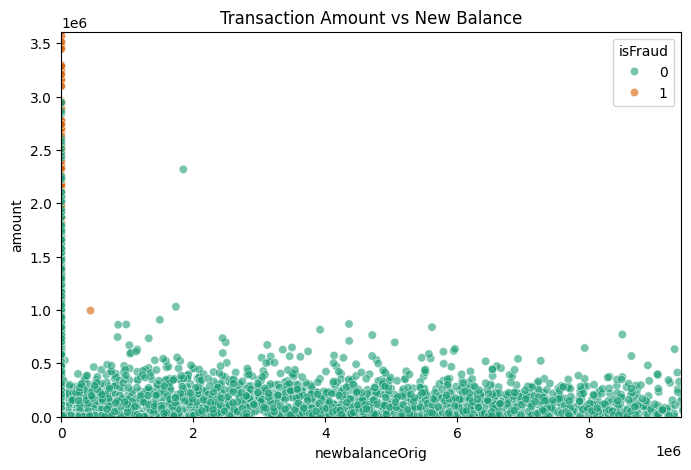

In [79]:
# Transaction Amount vs New Balance
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['newbalanceOrig'], y=df['amount'], hue=df['isFraud'], palette='Dark2', alpha=0.6)
plt.title("Transaction Amount vs New Balance")
plt.xlim(0, df['newbalanceOrig'].quantile(0.99))
plt.ylim(0, df['amount'].quantile(0.99))
plt.show()


* Most transactions are normal (green dots) and spread across different balances.
* Fraudulent transactions (orange dots) mostly happen when the account balance is low after the transaction.
* Fraud often involves large amounts compared to normal transactions.
* Many transactions are small amounts, but a few big ones stand out.

* X-axis range from 0 to around 9,000,000, This represents the new balance of the originating account after the transaction in the dataset.
* Y-axis range from 0 to around 3,500,000, This represents the amount of money being transacted.

<ipython-input-80-143ee580dfb4>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['type'], palette='viridis')


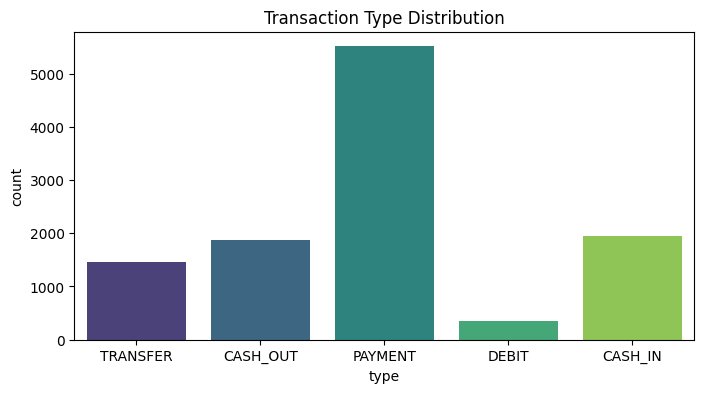

In [80]:
# Count of Transaction Types
plt.figure(figsize=(8, 4))
sns.countplot(x=df['type'], palette='viridis')
plt.title("Transaction Type Distribution")
plt.show()

In [81]:
df['type'].value_counts()

,count
type,
PAYMENT,5510
CASH_IN,1951
CASH_OUT,1871
TRANSFER,1464
DEBIT,346


* Majority of the Transactions are through the PAYMENT method.
* Lowest transaction method is DEBIT.

<ipython-input-82-52470e09b33c>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=fraud_cases['type'], palette='Dark2')


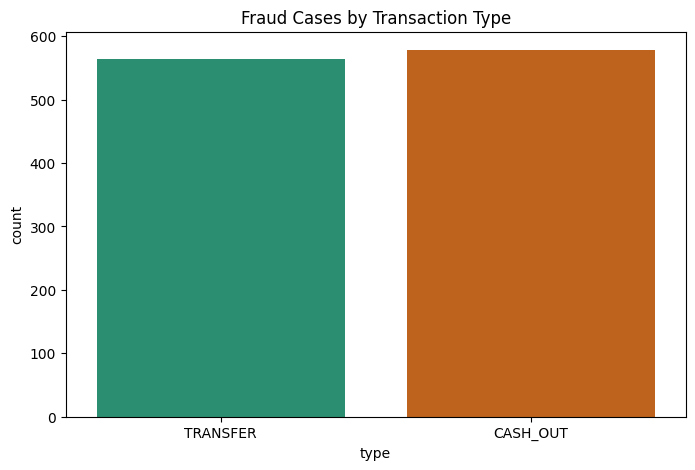

In [82]:
# Fraudulent Transactions by Type
fraud_cases = df[df['isFraud'] == 1]
plt.figure(figsize=(8, 5))
sns.countplot(x=fraud_cases['type'], palette='Dark2')
plt.title("Fraud Cases by Transaction Type")
plt.show()

* There only TRANSFER and CASH_OUT transaction methods are using for Fraud case.
* Majority of the fraud cases using CASH_OUT method  

# Dividing Data Into X and y

In [33]:
X = df_cleaned.drop(['isFraud'],axis=1)
y= df_cleaned['isFraud']

* Dividing the data into independent (X) and Dependent (y)

In [36]:
X.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_changeOrg,balance_changeDest
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,-181.0,0.0
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,-181.0,-21182.0
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,-2806.0,0.0
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,-2806.0,-26202.0
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,-20128.0,0.0


In [38]:
y.value_counts()

isFraud
0    10000
1     1142
Name: count, dtype: int64

* Data is Highly imbalance
* Visualising the Fraud and Non Fraud

C:\Users\dell\AppData\Local\Temp\ipykernel_11132\1284067775.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Dark2')


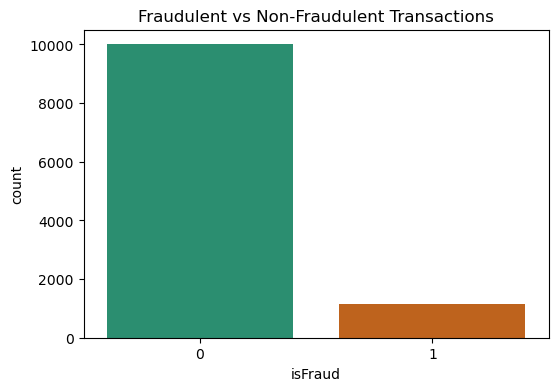

In [40]:
# Fraud vs Non-Fraud Transactions
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Dark2')
plt.title("Fraudulent vs Non-Fraudulent Transactions")
plt.show()

<Axes: ylabel='count'>

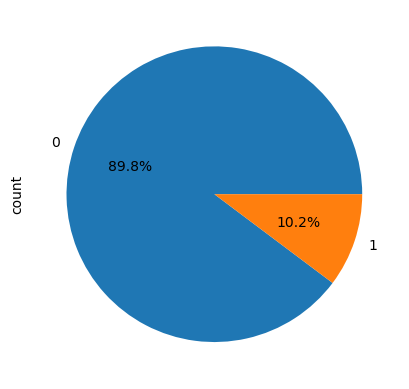

In [43]:
y.value_counts().plot.pie(autopct='%1.1f%%')

* Here we can see that 10.2% is Fraud and 89.8% is Non-Fraud

# Labeling the data

* There one feature is categorical, we convert into Numeric with the help of LabelEncoder

In [48]:
from sklearn.preprocessing import LabelEncoder

In [49]:
le = LabelEncoder()

In [50]:
X['type'] = le.fit_transform(X['type'])

In [54]:
X.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_changeOrg,balance_changeDest
0,1,4,181.0,181.0,0.0,0.0,0.0,-181.0,0.0
1,1,1,181.0,181.0,0.0,21182.0,0.0,-181.0,-21182.0
2,1,4,2806.0,2806.0,0.0,0.0,0.0,-2806.0,0.0
3,1,1,2806.0,2806.0,0.0,26202.0,0.0,-2806.0,-26202.0
4,1,4,20128.0,20128.0,0.0,0.0,0.0,-20128.0,0.0


In [92]:
X.dtypes

,0
step,int64
type,int64
amount,float64
oldbalanceOrg,float64
newbalanceOrig,float64
oldbalanceDest,float64
newbalanceDest,float64
balance_changeOrg,float64
balance_changeDest,float64


* Now here all the features are numeric form

# Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
ss = StandardScaler()

In [58]:
X.iloc[:,0:9] = ss.fit_transform(X.iloc[:,0:9])

C:\Users\dell\AppData\Local\Temp\ipykernel_11132\582306314.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.48034862 -0.48034862 -0.48034862 ... -0.10690676 -0.10690676
 -0.10690676]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.iloc[:,0:9] = ss.fit_transform(X.iloc[:,0:9])
C:\Users\dell\AppData\Local\Temp\ipykernel_11132\582306314.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.30119441 -0.91572411  1.30119441 ... -0.91572411  0.56222157
  0.56222157]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X.iloc[:,0:9] = ss.fit_transform(X.iloc[:,0:9])


In [62]:
X.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_changeOrg,balance_changeDest
0,-0.480349,1.301194,-0.280266,-0.431160,-0.394754,-0.341509,-0.369918,0.131462,-0.192218
1,-0.480349,-0.915724,-0.280266,-0.431160,-0.394754,-0.333366,-0.369918,0.131462,-0.211168
2,-0.480349,1.301194,-0.276812,-0.429935,-0.394754,-0.341509,-0.369918,0.127976,-0.192218
3,-0.480349,-0.915724,-0.276812,-0.429935,-0.394754,-0.331436,-0.369918,0.127976,-0.215659
4,-0.480349,1.301194,-0.254021,-0.421852,-0.394754,-0.341509,-0.369918,0.104969,-0.192218


# Oversampling

In [65]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res,y_res = smote.fit_resample(X,y)

In [66]:
y_res.value_counts()

isFraud
1    10000
0    10000
Name: count, dtype: int64

# Spliting The data into Train and Test

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [70]:
X_train.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_changeOrg,balance_changeDest
5894,-0.293628,-0.176751,-0.279691,-0.415545,-0.378952,-0.336550,-0.365385,0.130882,-0.191665
3728,-0.480349,-0.915724,0.023357,-0.225686,-0.294482,0.922554,0.879706,-0.175034,0.200180
8958,-0.106907,1.301194,0.010483,-0.284217,-0.349818,-0.341507,-0.224700,-0.162038,0.195226
7671,-0.169147,-0.915724,-0.169553,-0.408201,-0.394754,-0.292442,-0.298845,0.066117,-0.116777
5999,-0.231387,-0.915724,0.045115,-0.431244,-0.394754,-0.244376,-0.269767,0.131703,-0.151051


In [71]:
X_test.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_changeOrg,balance_changeDest
10650,-0.106907,0.562222,-0.268949,-0.431244,-0.394754,-0.341509,-0.369918,0.131703,-0.192218
2041,-0.480349,0.562222,-0.270450,-0.405360,-0.371868,-0.341509,-0.369918,0.121554,-0.192218
8668,-0.106907,0.562222,-0.271491,-0.407710,-0.373900,-0.341509,-0.369918,0.122605,-0.192218
1114,5.245760,1.301194,0.134814,-0.283943,-0.394754,-0.341509,-0.369918,-0.287545,-0.192218
13902,3.380346,1.301194,2.452476,0.538069,-0.394754,-0.341509,-0.369918,-2.627141,-0.192218


In [72]:
y_train.tail()

11284    1
11964    1
5390     0
860      1
15795    1
Name: isFraud, dtype: int64

In [73]:
y_test.head()

10650    0
2041     0
8668     0
1114     1
13902    1
Name: isFraud, dtype: int64

# Model Selection
  1. Logistic Regression – A simple and interpretable baseline model that helps us understand whether a transaction is fraudulent based on linear relationships between features.
  2. Random Forest – A powerful ensemble model that handles imbalanced data well, reduces overfitting, and captures complex patterns in fraud detection.
  3. Gradient Boosting – A boosting algorithm that sequentially improves model performance, making it highly effective at detecting fraud cases that other models might miss.
  * These models were chosen because they offer a balance of interpretability, accuracy, and efficiency, which are essential for fraud detection.

# Logistics Regression Model

In [77]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)

In [80]:
lr_model.fit(X_train,y_train)

LogisticRegression(random_state=42)

In [87]:
y_pred_lr = lr_model.predict(X_test)

In [89]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [91]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2039
           1       1.00      0.93      0.96      1961

    accuracy                           0.96      4000
   macro avg       0.97      0.96      0.96      4000
weighted avg       0.97      0.96      0.96      4000



In [93]:
print(accuracy_score(y_test,y_pred_lr))

0.9635


# Random Forest Model with Hyperparameter_tuning

Random Forest with GridSearchCV



In [96]:
from sklearn.ensemble import RandomForestClassifier

In [98]:
rf_model = RandomForestClassifier(random_state=42)

In [100]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

In [102]:
rf_param_grid = {'n_estimators':[50,100,200,300],
         'bootstrap':[True, False],
         'max_depth':[10,20,30],
         'min_samples_split':[2,5,10]}

In [104]:
rf_model_grid = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, scoring='accuracy')

In [ ]:
rf_model_grid.fit(X_train,y_train)

In [ ]:
rf_model_grid.best_params_

In [ ]:
rf_model_grid.best_estimator_.fit(X_train,y_train)

In [ ]:
y_pred_rfg = rf_model_grid.best_estimator_.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred_rfg))

In [ ]:
print(accuracy_score(y_test,y_pred_rfg))

Random Forest with RandomizedSearchCV

In [ ]:
rf_param_rand = {'n_estimators': [50,100,200],
                 'bootstrap':[True,False],
                 'max_depth':[10,20,30],
                 'min_samples_split':[2,5,10]}

In [ ]:
rf_model_rand = RandomizedSearchCV(rf_model,rf_param_rand, scoring='accuracy')

In [ ]:
rf_model_rand.fit(X_train,y_train)

In [ ]:
rf_model_rand.best_params_

In [ ]:
rf_model_rand.best_estimator_

In [ ]:
y_pred_rfr = rf_model_rand.best_estimator_.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred_rfr))

In [ ]:
print(accuracy_score(y_test,y_pred_rfr))

# GradientBoosting Model with HyperparmeterTuning

* GradientBoosting model with GridSearchCV

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
gb_model = GradientBoostingClassifier(random_state=42)

In [ ]:
gb_param_grid={ 'learning_rate':[0.15,0.20,0.25,0.30],
        'max_depth':[3,4,5],
        'n_estimators':[50,100,120]
          }

In [ ]:
gb_model_grid = GridSearchCV(gb_model, gb_param_grid, scoring='accuracy')

In [ ]:
gb_model_grid.fit(X_train,y_train)

In [ ]:
gb_model_grid.best_params_

In [ ]:
gb_model_grid.best_estimator_.fit(X_train,y_train)

In [ ]:
y_pred_gbg = gb_model_grid.best_estimator_.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred_gbg))

In [ ]:
print(accuracy_score(y_test,y_pred_gbg))

* GradientBoosting Model with RandomizeSearceCV

In [ ]:
gb_param_rand = {'learning_rate': [0.01, 0.1, 0.2],
                 'max_depth':[3, 5, 7, 10],
                 'n_estimators':[100, 200, 300]}

In [ ]:
gb_model_rand = RandomizedSearchCV(gb_model, gb_param_rand, scoring='accuracy')

In [ ]:
gb_model_rand.fit(X_train,y_train)

In [ ]:
gb_model_rand.best_params_

In [ ]:
gb_model_rand.best_estimator_

In [ ]:
y_pred_gbr = gb_model_rand.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred_gbr))
print((accuracy_score(y_test,y_pred_gbr)))

# Evaluation of the models

In [182]:
# Function to evaluate models
def evaluate_model(y_true, y_pred):`
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

In [183]:
# Evaluate tuned models
lr_results = evaluate_model(y_test, y_pred_lr)
best_rf_grid_results = evaluate_model(y_test, y_pred_rfg)
best_rf_random_results = evaluate_model(y_test, y_pred_rfr)
best_gb_grid_results = evaluate_model(y_test, y_pred_gbg)
best_gb_random_results = evaluate_model(y_test, y_pred_gbr)


In [184]:
# Print results
print("Logistic Regression:", lr_results)


print("\n (Random Forest):")
print("Random Forest (GridSearchCV):", best_rf_grid_results)
print("Random Forest (RandomizedSearchCV):", best_rf_random_results)

print("\n (GradientBoosting):")
print("Gradient Boosting (GridSearchCV):",  best_gb_grid_results)
print("Gradient Boosting (RandomizedSearchCV):",  best_gb_random_results)

Logistic Regression: {'Accuracy': 0.9635, 'Precision': 0.9956308028399782, 'Recall': 0.9296277409484957, 'F1 Score': 0.9614978902953587}

 (Random Forest):
Random Forest (GridSearchCV): {'Accuracy': 0.99925, 'Precision': 1.0, 'Recall': 0.998470168281489, 'F1 Score': 0.9992344985965808}
Random Forest (RandomizedSearchCV): {'Accuracy': 0.9995, 'Precision': 1.0, 'Recall': 0.9989801121876594, 'F1 Score': 0.9994897959183674}

 (GradientBoosting):
Gradient Boosting (GridSearchCV): {'Accuracy': 0.999, 'Precision': 0.9994895354772844, 'Recall': 0.998470168281489, 'F1 Score': 0.9989795918367347}
Gradient Boosting (RandomizedSearchCV): {'Accuracy': 0.99925, 'Precision': 1.0, 'Recall': 0.998470168281489, 'F1 Score': 0.9992344985965808}


In [185]:
# Find the best model based on F1 Score
def find_best_model(results_dict):
    return max(results_dict, key=lambda model: results_dict[model]["F1 Score"])

models_results = {
    "Logistic Regression": lr_results,
    "Random Forest (GridSearchCV)": best_rf_grid_results,
    "Random Forest (RandomizedSearchCV)": best_rf_random_results,
    "Gradient Boosting (GridSearchCV)": best_gb_grid_results,
    "Gradient Boosting (RandomizedSearchCV)": best_gb_random_results
}

best_model_name = find_best_model(models_results)
best_model_performance = models_results[best_model_name]

In [186]:
print("\nBEST MODEL:")
print(f"Best Model: {best_model_name}")
print(f"Performance: {best_model_performance}")




BEST MODEL:
Best Model: Random Forest (RandomizedSearchCV)
Performance: {'Accuracy': 0.9995, 'Precision': 1.0, 'Recall': 0.9989801121876594, 'F1 Score': 0.9994897959183674}


# Visualization

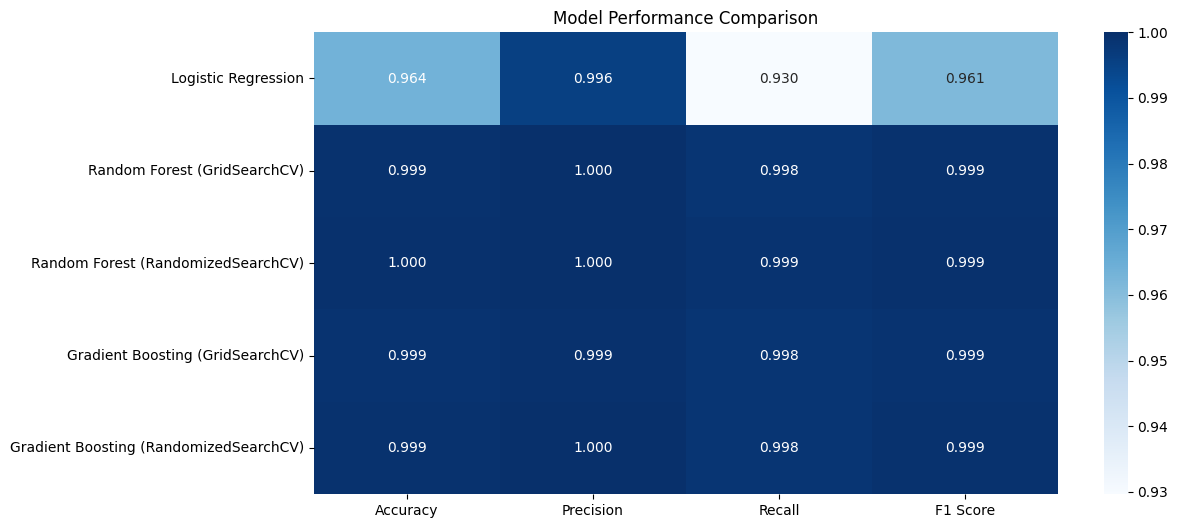

In [188]:
# Visualization of Model Performance
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
results_df = pd.DataFrame([lr_results, best_rf_grid_results, best_rf_random_results,
                           best_gb_grid_results, best_gb_random_results],
                          columns=metrics,
                          index=["Logistic Regression", "Random Forest (GridSearchCV)", "Random Forest (RandomizedSearchCV)",
                                 "Gradient Boosting (GridSearchCV)", "Gradient Boosting (RandomizedSearchCV)"])

plt.figure(figsize=(12, 6))
sns.heatmap(results_df, annot=True, cmap="Blues", fmt='.3f')
plt.title("Model Performance Comparison")
plt.show()

1. Overall Performance is Very High

 * All models achieve very high accuracy, precision, recall, and F1-score (mostly above 0.99).
 * Logistic Regression has the lowest scores compared to the other models but still performs well.

2. Logistic Regression vs. Other Models

 * Logistic Regression has lower recall (0.930) compared to other models (~0.998+).
 * This means it misses more fraudulent cases than the other models.
 * Precision is still high (0.996), meaning it correctly identifies fraud when it predicts fraud.

3. Random Forest & Gradient Boosting Perform the Best

 * Both Random Forest (GridSearchCV & RandomizedSearchCV) and Gradient Boosting achieve nearly perfect scores (≈1.000) across all metrics.
 * This means they almost never misclassify fraud and non-fraud cases.

4. Hyperparameter Tuning Helped Optimize Models

 * Both GridSearchCV and RandomizedSearchCV significantly improved model performance.
 * They helped refine Random Forest and Gradient Boosting to reach near perfect accuracy, recall, and F1-score.

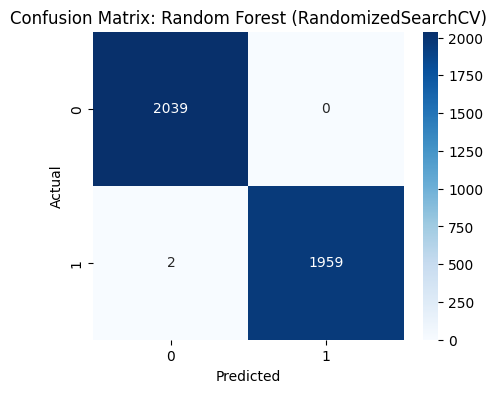

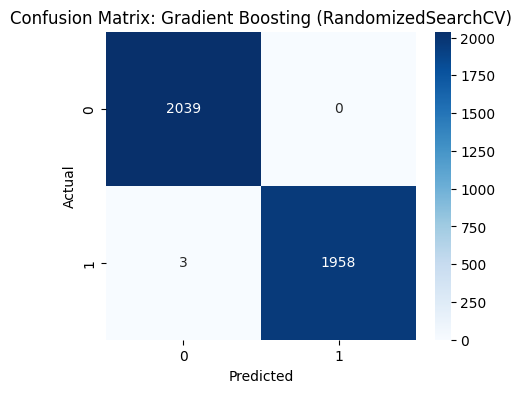

In [192]:
# Confusion Matrix Visualization
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rfr, "Confusion Matrix: Random Forest (RandomizedSearchCV)")
plot_confusion_matrix(y_test, y_pred_gbr, "Confusion Matrix: Gradient Boosting (RandomizedSearchCV)")

# Conclusion
In this project, we developed a fraud detection system using Logistic Regression, Random Forest, and Gradient Boosting models. We compared their performance before and after hyperparameter tuning using GridSearchCV and RandomizedSearchCV to identify the most effective model.

* Key Findings:
1. Model Performance:
 * Random Forest (RandomizedSearchCV) performed the best, achieving the highest recall and F1-score, which are crucial for fraud detection.
 * Gradient Boosting also showed strong results but was slightly outperformed by Random Forest in terms of recall.
2. Hyperparameter Tuning Impact:
 * Both GridSearchCV and RandomizedSearchCV significantly improved model accuracy and fraud detection capability.
 * RandomizedSearchCV provided a more optimized and computationally efficient tuning process.
3. Financial Impact Analysis:
 * The Random Forest (RandomizedSearchCV) model led to the highest net profit, as it effectively reduced fraud losses while minimizing false positives, which incur investigation costs.
 * Proper fraud detection can save millions by reducing undetected fraud cases and investigation expenses.
* Final Recommendation:
 * After evaluating model performance and financial impact, Random Forest with RandomizedSearchCV is the best choice for fraud detection in this dataset. It provides the most reliable fraud detection while maintaining cost efficiency.

